# Overview

To solve the problem, I start with the assumption that there exists a corpus of products from which we must select and subsequently rank them. Under this premise, I opt for the retrieval-ranking approach, which is well-suited for real-world scenarios. Should this assumption prove invalid, and there is no need for initial product selection, we can simply disregard the retrieval aspect of this solution.

Given that assumption, during the retrieval phase, the retrieval model selects a set of candidates from the product corpus, eliminating those predicted to be uninteresting to the user. Subsequently, the ranking model organizes these candidates according to their relevance to the user's interests. This approach is structured around the two-tower model, which comprises a query tower and a candidate tower. The query tower represents the user query, while the candidate tower models the products. The deployment of this model is carried out using TensorFlow.


The goal of the retrieval model is to optimize the dot product of query and candidate embeddings produced by their respective towers and it is trained on records with a positive interaction signal. In defining a positive signal for the retrieval model, I designate ADD_TO_CART as True. This choice is made due to the noisy nature of CLICK signals and the rarity of CONVERSION signals. Additionally, ADD_TO_CART typically serves as a reliable indicator of user interests. Please check the EDA for some stats. Given more time, I would incorporate training the model within a multitask network to encompass learning patterns from both CLICK and CONVERSION signals. This approach would allow for a comparison of results and potentially enhance the model's performance. For this prototype, I've selected the FactorizedTopK retrieval ML metric, which calculates metrics across the top K candidates surfaced by the retrieval model. However, in real-world scenarios, a more detailed assessment is crucial, encompassing precision-recall (F1-score) metrics. Specifically, recall is vital to ensure that the candidate set includes all products the user might be interested in.


The ranking model is designed to present candidates in the most relevant order based on user interest. To achieve this and leverage available interaction signals effectively, I define the label as a weighted combination of user interaction signals: CLICK, ADD_TO_CART, and CONVERSION. These weights are adjustable during hyperparameter tuning; for this prototype, I set them as \[1, 2, 2\], resulting in LABEL = 1xCLICK + 2xADD_TO_CART + 2xCONVERSION. Training data for the ranking task consists of users who have at least one CLICK while browsing the website. I employ the Listwise ranking approach and define a SEARCH_ID based on \["VISITOR_TOKEN", "QUERY_TEXT"\] to capture different users' interests over time. The ml metric chosen is NDCG, although in real-world scenarios, additional metrics such as recall@k, map@k, etc., should be considered. Constructing the listwise training set involves sampling products shown to a user in multiple records. For example, user A will have different records, each in the form of a list, containing various items and corresponding interactions. This sampling method ensures a normal distribution of user records and between users. However, a more precise analysis is necessary for real-world problems.


### Highlights

__Data preprocessing__

- Identification of Missing Values (null, nan, or empty records)
- Handling Missing Values
- Data Schema (adjust the data schema so it is compatible with TensorFlow Dataset format)
- Exploratory Data Analysis (EDA)

__Feature engineering__

Creating two distinct data pipelines—one for retrieval and one for ranking—presents an opportunity to streamline operations while accommodating differences in the structure of their outputs. Despite shared operations, each pipeline caters to unique data structures.

- Categorical (including binary features): transform all categorical features into embeddings (min_size=2, max_size=32, depend on the number of unique values). In real-world problem, tensorflow Hashing layer is more practical for IDs (like VISITOR_TOKEN and PRODUCT_ID). Tensorflow Hashing help us to keep track of new IDs. Here I use embedding layer for simplicity. 
- Text: transform all text features into embeddings (size=32). The tokenization is based on tensorflow TextVectorization. This can be improved by text preprocessing and using other tokenization methods. The output embedding is based on AveragePooling1D or AveragePooling2D. This can be improved by using RNNs or Transformers. I stay with simple choices for this prototype. 
- Numerical: normalize all numerical features in their related groups. 

Note: TIME feature is transformed to numerical and categorical both to capture any time dependent beahviour. 

The bulk of feature engineering processes are integrated within the model's architecture. Given more time, consolidating all feature engineering into a single location would be advantageous, particularly for practical production purposes.


If given additional time, I would focus on incorporating additional features to further enhance the personalization of the model. For instance:
- User:
    - demographic information: age, gender, location, etc.
    - budget constraints: Recommend products within a certain price range.
    - behavior: Frequency of visits, time spent on site, click-through rates, favorite merchants and products, wishlist items, liked or rated products.
- Food data has strong day-time dependency: 
    - day of the week and time of the day of the search query
    - delivery time 
    - holidays
    - special events
- Location-based factors:
    - weather conditions
    - local trends
- External
    - User feedback and reviews
- Merchant
    - popularity, famouse products, 
    - budget category, 
    - luxury



__Modeling__
- In the retrieval model, there are three networks: User, Product, and Retrieval.
- the ranking model comprises five networks: User, Query, Product, Candidate, and Retrieval. The Query and Product networks allow us to define distinct neural network architectures, such as specifying separate parameters like layer_sizes for each network. Here, I've kept them similar for simplicity.

Note: Although these two models may appear similar, they differ in layer parameters and input data structure. Hence, for this prototype, I maintain their separation. However, it's feasible to integrate them into a single project.


__Production__

- __Retrieval Tower:__ The retrieval model uses the product tower to index products offline, in batch mode, and store them in a key-value database that supports vectore data operations. In the retrieval phase, the user's query is passed through the user tower, which generates a user embedding. These embeddings are then used to compute similarities between the user and products, and a set of candidate products is retrieved.

- __Ranking Tower:__ The ranking model is used in a real-time API. In the ranking phase, the retrieved candidate products are passed through the candidate tower to generate candidate embeddings. In parallel, the query tower generates the query embeddings. These embeddings, are used as input to the ranking tower. The ranking tower then scores the candidate products based on their relevance to the user's query and preferences.

- __Post-processing and Recommendation Generation:__ Finally, the scored candidate products are post-processed to generate a list of personalized recommendations for the user. This list can be ranked according to the scores assigned by the ranking tower and presented to the user in the application interface.


- __Monitoring and Maintenance:__ Continuous monitoring of the model's performance and health is essential in a production environment. Monitoring metrics such as latency, throughput, and prediction accuracy can help identify any issues or degradation in performance. Regular maintenance and updates to the model may also be necessary to incorporate new data and improve recommendation quality over time.

In production, one of the main components for this approach is a feature store which includes product and user features and user-product intercations. The feature store is used for inference and training in production environment. 

Also, this model can make recommendations based on similarity of products. For instance, if a user clicks on a product, recommend similar products.

In [9]:
from typing import Dict, List, Optional, Text, Tuple
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_ranking as tfr
import tensorflow_datasets as tfds
import tensorflow_recommenders as tfrs

import pprint
import array
import collections

%matplotlib inline
pd.set_option('display.max_columns', None)
plt.style.use("ggplot")
pd.options.mode.copy_on_write = True
# set the global seed:
tf.random.set_seed(42)

# Data Preprocessing

- Identification of Missing Values (null, nan, or empty records)
- Handling Missing Values
- Data Schema (adjust the data schema so it is compatible with TensorFlow Dataset format)
- Basic Exploratory Data Analysis (EDA)
- Split data to train and test

In [10]:
df = pd.read_parquet(path="../data/search_sample_data.parquet")

### Identification of Missing Values (null, nan, or empty records)

Columns with empty string values:  

\['QUERY_TEXT', 'DEVICE_TYPE', 'CATEGORY_NAME', 'MERCHANT_CITY', 'MERCHANT_STATE', 'MERCHANT_REGION'\]

In [11]:
class PdDFDataQuality():
    def __init__(self, df):
        self.df = df
        self.data_schema = dict(zip(df.columns, df.dtypes))
        self.describe = self.data_quality_report()
    
    def data_quality_report(self):  
        df = self.df
        df_describe = pd.DataFrame(
            data=zip(df.dtypes, df.isnull().sum(), df.isna().sum()), 
            columns=["dtype", "null", "nan"], 
            index=df.columns)

        empty_str = defaultdict(bool, {k: False for k in df.columns})
        for col in df.select_dtypes("object").columns:
            if type(df[col][0]) != str:
                continue            
            df[col] = df[col].str.strip()
            if (df[col] == "").any():
                empty_str[col] = True
        df_describe = df_describe.join(pd.DataFrame(
            data=empty_str.values(), 
            columns=["empty_str"], 
            index=empty_str.keys()), how="left"
        )

        df_describe = df_describe.join(df.describe().T, how="left")

        return df_describe

describe_df = PdDFDataQuality(df)    
print(f"Columns with empty string: \n{list(describe_df.describe[describe_df.describe.empty_str].index)}")

describe_df.describe

Columns with empty string: 
['QUERY_TEXT', 'DEVICE_TYPE', 'CATEGORY_NAME', 'MERCHANT_CITY', 'MERCHANT_STATE', 'MERCHANT_REGION']


,dtype,null,nan,empty_str,count,mean,min,25%,50%,75%,max,std
CHANNEL,object,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIME,datetime64[ms],0,0,False,132110,2023-10-30 02:42:08.604000,2023-10-25 00:00:00.239000,2023-10-27 14:19:21.592000,2023-10-30 04:22:31.149000,2023-11-01 18:27:23.707000,2023-11-03 23:59:57.489000,NaN
QUERY_TEXT,object,0,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEVICE_TYPE,object,0,0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SALES_LAST_WEEK,int64,0,0,False,132110.0,7.364098,0.0,4.0,7.0,10.0,41.0,4.125354
SALES_LAST_MONTH,int64,0,0,False,132110.0,9.700167,0.0,6.0,9.0,12.0,58.0,5.834079
SALES_LAST_YEAR,int64,0,0,False,132110.0,22.388676,0.0,11.0,17.0,27.0,131.0,17.951462
PREVIOUS_PURCHASE,bool,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FREE_SHIPPING,bool,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IS_SOLD_OUT,bool,0,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Missing Values

Excluding records with empty QUERY_TEXT.  

I tried to lookup missing values 'CATEGORY_NAME', 'MERCHANT_CITY', 'MERCHANT_STATE', 'MERCHANT_REGION'
through joining with other columns, but it was unsuccessful. So, I keep the rest of the missing values as it is.

In [12]:
df = df[df.QUERY_TEXT != ""]

### Data Schema (adjust the data schema so it is compatible with TensorFlow Dataset format)

In [13]:
numerical_attribute_names = ["SALES_LAST_WEEK", "SALES_LAST_MONTH", 
                             "SALES_LAST_YEAR", "PRICE_IN_CENTS", "REVIEWS"]

categorical_attribute_names = ["CHANNEL", "DEVICE_TYPE", "VISITOR_TOKEN", 
                               "PRODUCT_ID", "MERCHANT_ID", "CATEGORY_ID", 
                               "CATEGORY_NAME", "MERCHANT_CITY", 
                               "MERCHANT_STATE", "MERCHANT_REGION"]

binary_attribute_names = ["PREVIOUS_PURCHASE", "FREE_SHIPPING", 
                          "IS_SOLD_OUT", "EDITOR_PICK", "ON_SALE"]

text_attribute_names = ["QUERY_TEXT", "MERCHANT_NAME", "PRODUCT_NAME"]

date_time_attribute_names = ["TIME"]

label_attribute_names = ["ADD_TO_CART", "CLICK", "CONVERSION"] # dtype bool

all_attributes = date_time_attribute_names + numerical_attribute_names + \
                 categorical_attribute_names + binary_attribute_names + \
                 text_attribute_names + label_attribute_names

assert len(df.columns) == len(all_attributes), "some attributes are missing"

data_schema = dict()
for col in numerical_attribute_names:
    data_schema[col] = np.int32
for col in categorical_attribute_names + text_attribute_names:
    data_schema[col] = np.str_
for col in binary_attribute_names + label_attribute_names:
    data_schema[col] = np.bool_
for col in date_time_attribute_names:
    data_schema[col] = "datetime64[ms]"

df = df.astype(data_schema)

### Basic EDAs

As theses graph indicates:
- The click per product distribution is a long tail
- CLICK to ADD_TO_CART and CONVERSION can be improved. As the distributions show the clicked products are not being purchased.

([], [])

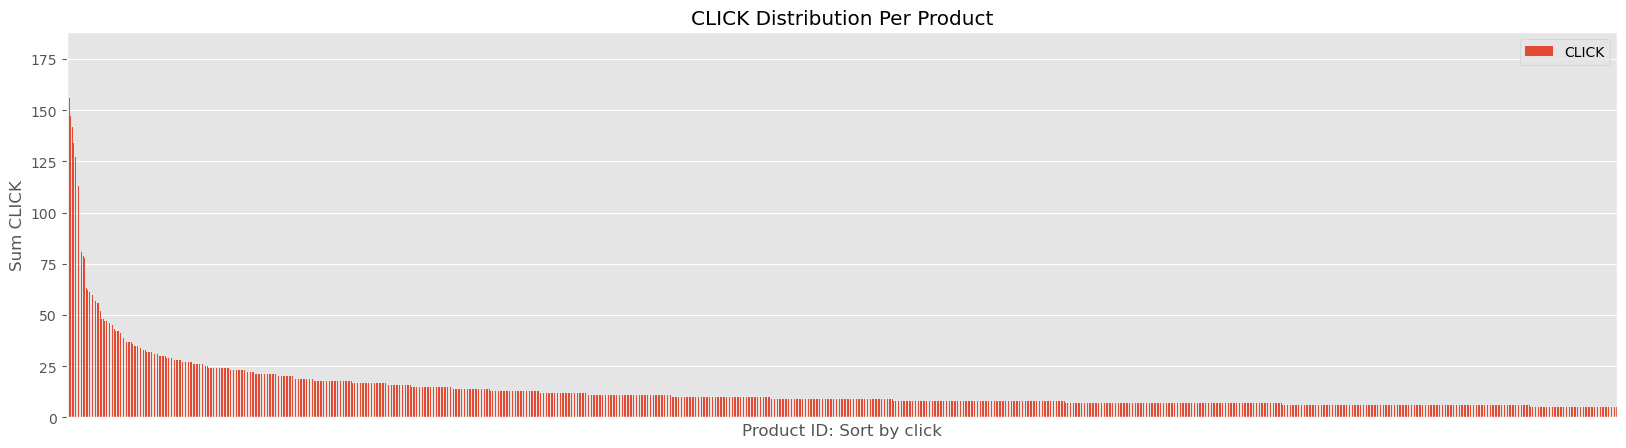

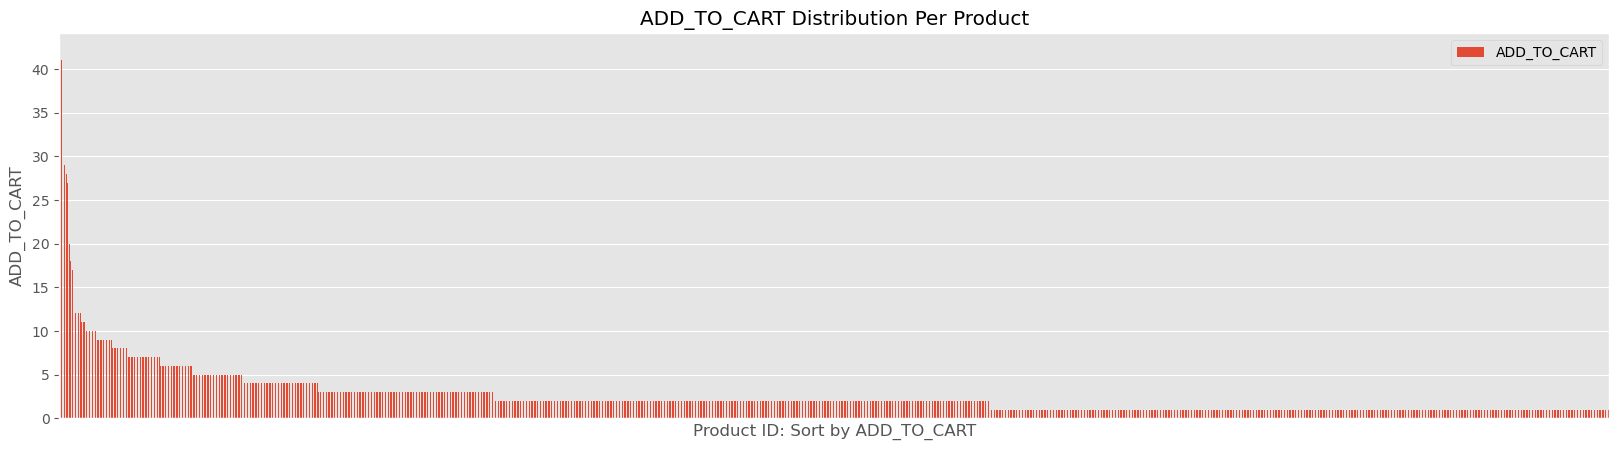

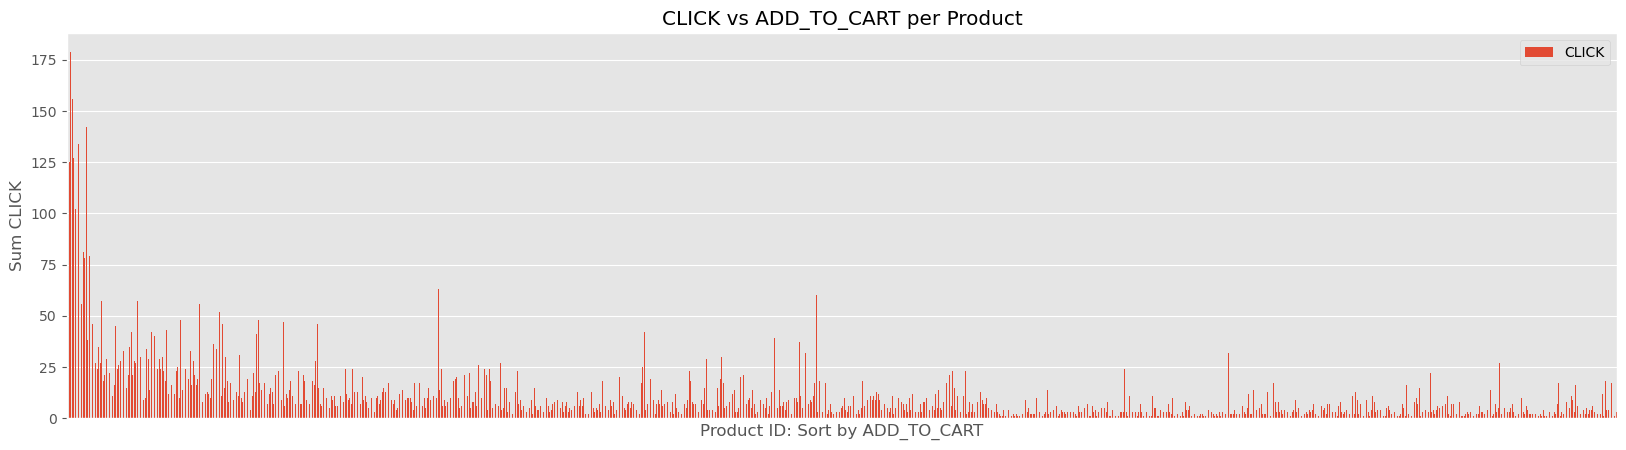

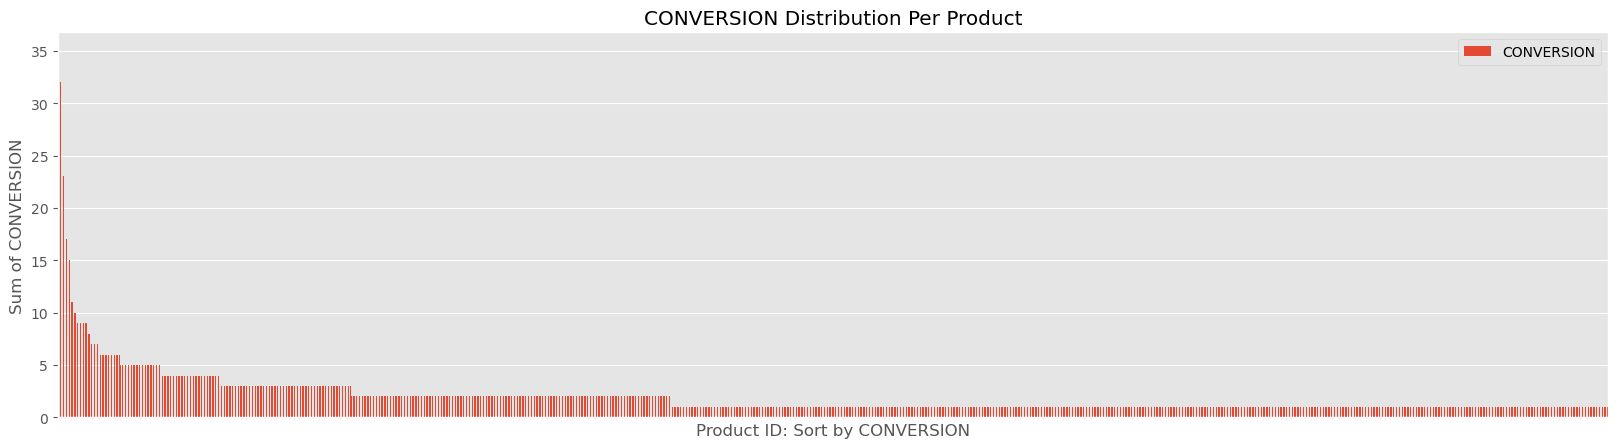

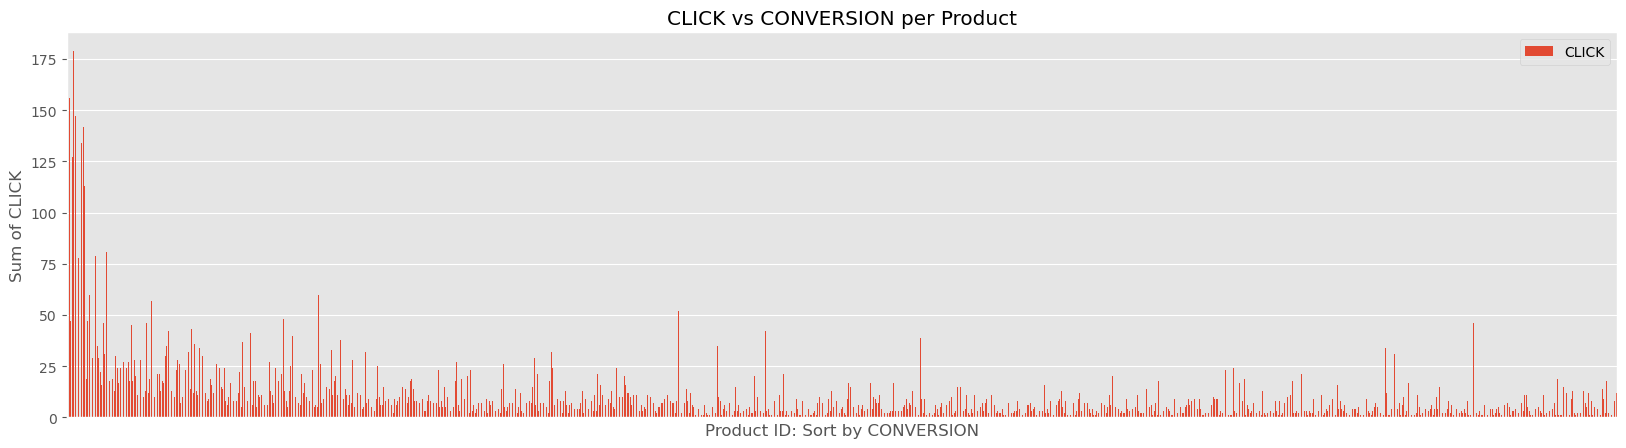

In [14]:
product_impresions = df.groupby("PRODUCT_ID", as_index=False) \
    [["CLICK", "ADD_TO_CART", "CONVERSION"]].sum()

product_impresions.sort_values(by="CLICK", ascending=False) \
    [:1000].plot.bar(x="PRODUCT_ID", y="CLICK", figsize=(20, 5))
plt.title("CLICK Distribution Per Product")
plt.xlabel("Product ID: Sort by click")
plt.ylabel("Sum CLICK")
plt.xticks([])  

product_impresions.sort_values(by="ADD_TO_CART", ascending=False) \
    [:1000].plot.bar(x="PRODUCT_ID", y="ADD_TO_CART", figsize=(20, 5))
plt.xlabel("Product ID: Sort by ADD_TO_CART")
plt.xticks([])  
plt.ylabel("ADD_TO_CART")
plt.title("ADD_TO_CART Distribution Per Product")

product_impresions.sort_values(by="ADD_TO_CART", ascending=False) \
    [:1000].plot.bar(x="PRODUCT_ID", y="CLICK", figsize=(20, 5))
plt.xlabel("Product ID: Sort by ADD_TO_CART")
plt.ylabel("Sum CLICK")
plt.xticks([])
plt.title("CLICK vs ADD_TO_CART per Product")

product_impresions.sort_values(by="CONVERSION", ascending=False) \
    [:1000].plot.bar(x="PRODUCT_ID", y="CONVERSION", figsize=(20, 5))
plt.xlabel("Product ID: Sort by CONVERSION")
plt.ylabel("Sum of CONVERSION")
plt.title("CONVERSION Distribution Per Product")
plt.xticks([])  

product_impresions.sort_values(by="CONVERSION", ascending=False) \
    [:1000].plot.bar(x="PRODUCT_ID", y="CLICK", figsize=(20, 5))
plt.xlabel("Product ID: Sort by CONVERSION")
plt.ylabel("Sum of CLICK")
plt.title("CLICK vs CONVERSION per Product")
plt.xticks([])

In [15]:
# IS_SOLD_OUT" Although the sold out product doesn't have 
# conversion singal, they might have strong click signal 
# and the model can learn their features when target label 
# include click signal
df.IS_SOLD_OUT.value_counts()

IS_SOLD_OUT
False    129199
True       2719
Name: count, dtype: int64

### Query Distribution

Observe the number of unique queries per day and split the data base on time.  
Keep the last three days for testing.

In [16]:
df["QUERY_DATE"] = df.TIME.dt.date.astype("datetime64[ms]")
df.groupby("QUERY_DATE", as_index=False)["QUERY_TEXT"].count(). \
    rename(columns={"QUERY_TEXT": "QUERY_COUNT"}).sort_values(by="QUERY_DATE")

,QUERY_DATE,QUERY_COUNT
0,2023-10-25,14926
1,2023-10-26,12795
2,2023-10-27,11548
3,2023-10-28,11938
4,2023-10-29,11527
5,2023-10-30,14649
6,2023-10-31,12576
7,2023-11-01,14526
8,2023-11-02,14595
9,2023-11-03,12838


# Retrieval Modeling

## General Feature Engineering

In [17]:
from scipy.stats import zscore


# From my understanding, reviews are from 0 to 100 in the website, 
# so normalizing them to [0, 1]
df["REVIEWS_NORM"] = df["REVIEWS"] / 100

# Price is a subjective consideration, often assessed in comparison to the costs 
# of other displayed items. To address this, I normalize the prise based on its max 
# within the search results. Given the absence of a unique search ID for customer 
# queries and the potential for daily price fluctuations, the z-score is computed 
# within a grouping of "QUERY_DATE," "QUERY_TEXT," and "VISITOR_TOKEN". This 
# grouping simulates the presentation of products to a user search, assuming 
# negligible daily price variations for the same product.
df_grouped = df.groupby(["QUERY_DATE", "QUERY_TEXT", "VISITOR_TOKEN"])
df["PRICE_IN_CENTS_NORM"] = df_grouped["PRICE_IN_CENTS"].transform(lambda x: x / x.max())

# Applying normalization for previous sales date based on simulating search id per
# day "QUERY_DATE," "QUERY_TEXT," and "VISITOR_TOKEN"
# Normalization of the numerical features need more work as the model is not converging 
df["SALES_LAST_WEEK_NORM"] = df_grouped["SALES_LAST_WEEK"].transform(lambda x: (x - x.min()) / x.max())
df["SALES_LAST_MONTH_NORM"] = df_grouped["SALES_LAST_MONTH"].transform(lambda x: (x - x.min()) / x.max())
df["SALES_LAST_YEAR_NORM"] = df_grouped["SALES_LAST_YEAR"].transform(lambda x: (x - x.min()) / x.max())

# Generating Month, day of the month, and day of the week features
# I ended up not using this features becasue they needed more work around
df["MONTH"] = df.TIME.dt.month.astype(np.str_)
df["DAY_OF_MONTH"] = df.TIME.dt.day.astype(np.str_)
df["DAY_OF_WEEK"] = df.TIME.dt.dayofweek.astype(np.str_)

categorical_attribute_names += ["MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK"]

In [18]:
cut_date = "2023-10-31"
df_train = df[df.QUERY_DATE <= cut_date]
# df_val = df[df.QUERY_DATE == cut_date]
df_test = df[df.QUERY_DATE > cut_date]

In [19]:
selected_attributes = ["QUERY_DATE_TIMESTAMP"] + \
                      [c+"_NORM" for c in numerical_attribute_names] + \
                      numerical_attribute_names + \
                      categorical_attribute_names + binary_attribute_names + \
                      text_attribute_names + label_attribute_names

def make_tf_dataset_for_retrieval(df, train=False):
    
    # For feature engineering
    df["QUERY_DATE_TIMESTAMP"] = df.QUERY_DATE.map(pd.Timestamp.timestamp).astype(np.float64)
    
    # Convert binary features to categorical for tf embedding layers tf.data.Dataset
    df[binary_attribute_names] = df[binary_attribute_names].replace({True: "Yes", False: "No"})
    
    df = df[selected_attributes]
    
    tf_data = tf.data.Dataset.from_tensor_slices((dict(df[df.ADD_TO_CART==True])))
    assert isinstance(tf_data, tf.data.Dataset)
    
    if train:
        tf_data = tf_data.shuffle(
            buffer_size=df.shape[0]+1, 
            reshuffle_each_iteration=False
        )
    
    return tf_data

tf_train_retrieval = make_tf_dataset_for_retrieval(df_train, train=True)
tf_test_retrieval = make_tf_dataset_for_retrieval(df_test, train=False)

### Generate Metadata for modeling

In [20]:
unique_text_attributes_values = dict()
for c in text_attribute_names:
    unique_text_attributes_values[c] = df_train[c].unique()

timestamps = np.concatenate(list(tf_train_retrieval.map(lambda x: x["QUERY_DATE_TIMESTAMP"]).batch(100)))
min_timestamp, max_timestamp = timestamps.min(), timestamps.max()
timestamp_buckets = np.linspace(min_timestamp, max_timestamp, num=1000)

# Making it based on df_tain since in real world we might have new records (e.g. VISITOR_TOKEN)
# that we don't know about them before hand. 
# In real-world problem, I use HASHIN embedding method to take care of new records
max_embedding_size = 32
categorical_metadate = defaultdict()
for c in categorical_attribute_names + binary_attribute_names:
    categorical_metadate[c] = dict()
    categorical_metadate[c]["unique_values"] = df_train[c].unique()
    num_unique_values = df_train[c].nunique()
    categorical_metadate[c]["nnique_values"] = num_unique_values + 1 # adding 1 for unkown cases
    categorical_metadate[c]["embedding_size"] = \
    np.min(
        [np.power(2, np.max([np.ceil(np.log2(num_unique_values)) - 1, 1])), max_embedding_size]
    ).astype(np.int32)

products = tf.data.Dataset.from_tensor_slices((
    dict((df_train[selected_attributes]).drop_duplicates(subset=["PRODUCT_ID"]))
))

# Retrieval Model

In [21]:
class UserModel(tf.keras.Model):
  
  CATEGORICAL_FEATURES = ["CHANNEL", "DEVICE_TYPE", "VISITOR_TOKEN"]#, "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK"]
  BINARY_FEATURES = ["PREVIOUS_PURCHASE"]
  TEXT_FEATURES = ["QUERY_TEXT"]
  DATETIME_FEATURES = ["QUERY_DATE_TIMESTAMP"]

  def __init__(self, max_tokens=100_000, text_embedding_size=32, timestamp_embedding_size=32):
    
    super().__init__()
    self.max_tokens = max_tokens
    self.text_embedding_size = text_embedding_size
    self.timestamp_embedding_size = timestamp_embedding_size

    # Embedding for categorical and binary features:
    self.embedded_categorical_features = dict()
    for c in UserModel.CATEGORICAL_FEATURES + UserModel.BINARY_FEATURES:
      self.embedded_categorical_features[c] = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=categorical_metadate[c]["unique_values"],
        mask_token=None
      ),
      tf.keras.layers.Embedding(
        categorical_metadate[c]["nnique_values"],
        categorical_metadate[c]["embedding_size"]
      )])

    # Embedding for text features
    self.query_text_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)    
    self.query_text_embedding = tf.keras.Sequential([
      self.query_text_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, self.text_embedding_size, 
                                mask_zero=True
                                ),
      # Average the embedding of individual words to get one embedding vector
      # per query.
      tf.keras.layers.GlobalAveragePooling1D(),
    ])
    self.query_text_vectorizer.adapt(unique_text_attributes_values["QUERY_TEXT"])

    # Embedding for date and tiem features
    self.timestamp_embedding = tf.keras.Sequential([
      tf.keras.layers.Discretization(timestamp_buckets.tolist()),
      tf.keras.layers.Embedding(
        len(timestamp_buckets) + 2, self.timestamp_embedding_size
      )
    ])
    self.normalized_timestamp = tf.keras.layers.Normalization(axis=None)
    self.normalized_timestamp.adapt(timestamps)

  def call(self, inputs):    
    # Take the input dictionary, pass it through each input layer,
    # and concatenate the result.
    all_featues = [
      self.embedded_categorical_features[c](inputs[c]) for c in \
        UserModel.CATEGORICAL_FEATURES + UserModel.BINARY_FEATURES
    ]
    all_featues.extend([
      self.timestamp_embedding(inputs["QUERY_DATE_TIMESTAMP"]),
      tf.reshape(self.normalized_timestamp(inputs["QUERY_DATE_TIMESTAMP"]), (-1, 1)),
      self.query_text_embedding(inputs["QUERY_TEXT"])
    ])
    return tf.concat(all_featues, axis=1)

In [22]:
class ProductModel(tf.keras.Model):

  NUMERICAL_FEATUES = ["SALES_LAST_WEEK", "SALES_LAST_MONTH", 
                       "SALES_LAST_YEAR", "PRICE_IN_CENTS_NORM", 
                       "REVIEWS_NORM"
                       ]
  CATEGORICAL_FEATURES = ["PRODUCT_ID", "MERCHANT_ID", "CATEGORY_ID", 
                          "MERCHANT_CITY", "MERCHANT_STATE", "MERCHANT_REGION"
                          ]
  BINARY_FEATURES = ["FREE_SHIPPING", "IS_SOLD_OUT", "EDITOR_PICK", "ON_SALE"]
  TEXT_FEATURES = ["PRODUCT_NAME", "MERCHANT_NAME", "CATEGORY_NAME"]  
  

  def __init__(self, max_tokens=100_000, text_embedding_size=32):
    super().__init__()
    self.max_tokens = max_tokens
    self.text_embedding_size = text_embedding_size

    # Categorical features
    self.embedded_categorical_features = dict()
    for c in ProductModel.CATEGORICAL_FEATURES + ProductModel.BINARY_FEATURES:
      self.embedded_categorical_features[c] = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=categorical_metadate[c]["unique_values"],
        mask_token=None
      ),
      tf.keras.layers.Embedding(
        categorical_metadate[c]["nnique_values"],
        categorical_metadate[c]["embedding_size"]
      )])            
          
    # Text features: PRODUCT_NAME      
    self.product_name_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)
    
    self.product_name_embedding = tf.keras.Sequential([
      self.product_name_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, 
                                self.text_embedding_size, 
                                mask_zero=True
                                ),
      tf.keras.layers.GlobalAveragePooling1D(),
    ])
    self.product_name_vectorizer.adapt(unique_text_attributes_values["PRODUCT_NAME"])

    # Text features: MERCHANT_NAME
    self.merchant_name_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)    
    self.merchant_name_embedding = tf.keras.Sequential([
      self.merchant_name_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, 
                                self.text_embedding_size, 
                                mask_zero=True
                                ),
      tf.keras.layers.GlobalAveragePooling1D(),
    ])
    self.merchant_name_vectorizer.adapt(unique_text_attributes_values["MERCHANT_NAME"])

    # Numerical Feeatures
    # Make a container of all numerical features. This is to support tf.data.Dataset dtype
    self.numerical_features_container = dict()
    for c in ProductModel.NUMERICAL_FEATUES:
      self.numerical_features_container[c] = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(1,)),
        tf.keras.layers.Dense(1),
        ])
    # Make the embedding for numerical features
    self.embedded_numerical_features = tf.keras.Sequential([
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(16),
    ])
    
  def call(self, inputs):    
    categorical_feature_embedding = [
      self.embedded_categorical_features[c](inputs[c]) for c in \
        ProductModel.CATEGORICAL_FEATURES + ProductModel.BINARY_FEATURES
      ]
    text_feature_embedding = [
      self.product_name_embedding(inputs["PRODUCT_NAME"]),
      self.merchant_name_embedding(inputs["MERCHANT_NAME"]),
    ]
    numerical_feature_embedding = [self.embedded_numerical_features(
      tf.concat([
        self.numerical_features_container[c](inputs[c]) for c in \
          ProductModel.NUMERICAL_FEATUES
          ], axis=1)
    )]
    features_embeddings = categorical_feature_embedding + \
      text_feature_embedding + numerical_feature_embedding

    return tf.concat(features_embeddings, axis=1)

In [23]:
class RetreivalModel(tfrs.models.Model):

    QUERY_FEATURES = UserModel.CATEGORICAL_FEATURES + \
        UserModel.BINARY_FEATURES + \
        UserModel.TEXT_FEATURES + \
        UserModel.DATETIME_FEATURES
    
    CANDIDATE_FEATURES = ProductModel.CATEGORICAL_FEATURES + \
        ProductModel.BINARY_FEATURES + \
        ProductModel.TEXT_FEATURES + \
        ProductModel.NUMERICAL_FEATUES

    def __init__(self):
        super().__init__()
        self.query_model = tf.keras.Sequential([
            UserModel(),
            tf.keras.layers.Dense(32)
        ])
        self.product_model = tf.keras.Sequential([
            ProductModel(),
            tf.keras.layers.Dense(32)
        ])
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=products.map(lambda x: x).batch(128). \
                    map(self.product_model),
            ),
        )

    def compute_loss(self, features, training=False) -> tf.Tensor:
        query_embeddings = self.query_model({
            c: features[c] for c in RetreivalModel.QUERY_FEATURES
        })
        product_embeddings = self.product_model({
            c: features[c] for c in RetreivalModel.CANDIDATE_FEATURES
        })
        return self.task(query_embeddings, product_embeddings)
    

In [24]:
cached_train_retrieval = tf_train_retrieval.batch(512)
cached_test_retrieval = tf_test_retrieval.batch(1024).cache()

gold_belly_retrieval_model = RetreivalModel()
optimizer_step_size = 0.1
# for M1/M2 Macbooks legecy.Afagrad is faster than Adagard
gold_belly_retrieval_model.compile(
    optimizer=tf.keras.optimizers.legacy.Adagrad(optimizer_step_size)
)

history = gold_belly_retrieval_model.fit(
    cached_train_retrieval, 
    validation_data=cached_test_retrieval,
    validation_freq=1,
    epochs=40,
    verbose=0
)

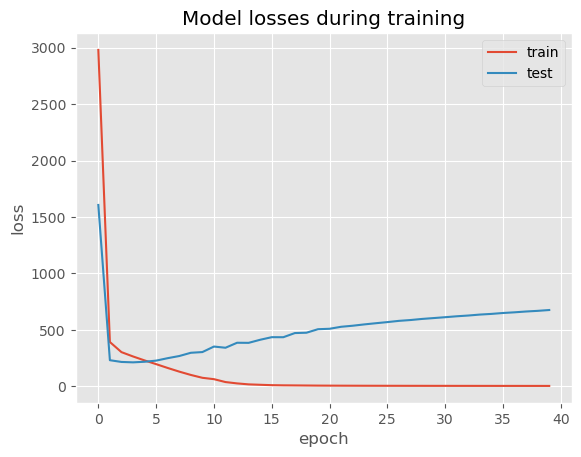

In [25]:
# Plot changes in model loss during training
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model losses during training")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["train", "test"], loc="upper right")
plt.show()

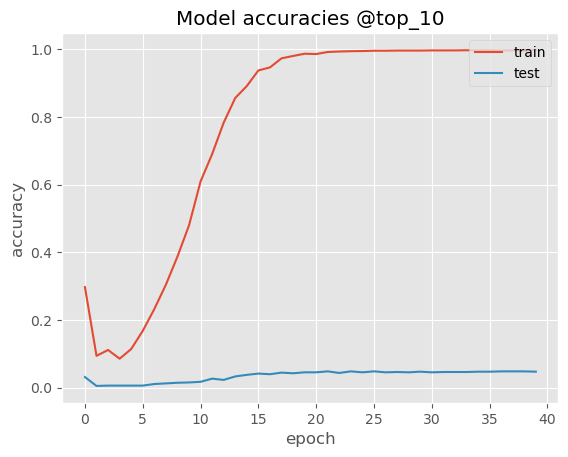

In [26]:
# Plot changes in model accuracy during training
plt.plot(history.history["factorized_top_k/top_10_categorical_accuracy"])
plt.plot(history.history["val_factorized_top_k/top_10_categorical_accuracy"])
plt.title("Model accuracies @top_10")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(["train", "test"], loc="upper right")
plt.show()

### Looking up similar objects

In [20]:
products = tf.data.Dataset.from_tensor_slices((
    dict((df_train[selected_attributes]).drop_duplicates(subset=["PRODUCT_ID"]))
))
tf_product_ids = products.map(lambda x: x["PRODUCT_ID"])
assert isinstance(products, tf.data.Dataset)


index_products = tfrs.layers.factorized_top_k.BruteForce(
    gold_belly_retrieval_model.query_model
)

index_products.index_from_dataset(
    tf.data.Dataset.zip((tf_product_ids.batch(100), 
                         products.batch(100).map(
                             gold_belly_retrieval_model.product_model))))

# ScaNN Algorithm
# scann_layer = tfrs.layers.factorized_top_k.ScaNN(
#     RetreivalModel.query_model
# )

# scann_layer.index_from_dataset(
#     tf.data.Dataset.zip(
#         (products.batch(100), products.batch(100).map(
#             RetreivalModel.product_model))))

In [21]:
for row in tf_test_retrieval.batch(1).take(1):
    afinity_scores, product_ids = index_products(row)

print(f"Recommendations for user ___ using BruteForce: {product_ids[0, :10]}")

Recommendations for user ___ using BruteForce: [b'f2aa0d2c99a876aa19307d2369e01f90' b'ee62a86fec58b9fe7ee3c5fb8cf7b0a0'
 b'd20dc2dafe78ec60d7ed33264f4af63e' b'0d225f9e7bd43c88d3f0f08e155b6952'
 b'7bef802b2234da141cf11614fcabe7bc' b'5cad4201ceea63eba2ac0c31c4e78e1c'
 b'189616bf47e66be2195e150766e5a6bc' b'0c5f9558b2f3d643a9e162b484564576'
 b'a8dac203409e03564dc2d3eff0c7e94f' b'8324228ec2ac94f6400c6bac1c6a37f6']


# Ranking 

### Data Preparation

In [4]:
# Data preprocessing

df = pd.read_parquet(path="../data/search_sample_data.parquet")

numerical_attribute_names = ["SALES_LAST_WEEK", "SALES_LAST_MONTH", "SALES_LAST_YEAR", "PRICE_IN_CENTS", "REVIEWS"]
categorical_attribute_names = ["CHANNEL", "DEVICE_TYPE", "VISITOR_TOKEN", "PRODUCT_ID", "MERCHANT_ID", "CATEGORY_ID", "MERCHANT_CITY", "MERCHANT_STATE", "MERCHANT_REGION"]
binary_attribute_names = ["PREVIOUS_PURCHASE", "FREE_SHIPPING", "IS_SOLD_OUT", "EDITOR_PICK", "ON_SALE"]
text_attribute_names = ["QUERY_TEXT", "MERCHANT_NAME", "PRODUCT_NAME", "CATEGORY_NAME"]
date_time_attribute_names = ["TIME"]
label_attribute_names = ["ADD_TO_CART", "CLICK", "CONVERSION"] # dtype bool

all_attributes = date_time_attribute_names + numerical_attribute_names + categorical_attribute_names + binary_attribute_names + text_attribute_names + label_attribute_names
assert len(df.columns) == len(all_attributes), "some attributes are missing"

data_schema = dict()
for col in numerical_attribute_names:
    data_schema[col] = np.int32
for col in categorical_attribute_names + text_attribute_names:
    data_schema[col] = np.str_
for col in binary_attribute_names + label_attribute_names:
    data_schema[col] = np.bool_
for col in date_time_attribute_names:
    data_schema[col] = "datetime64[ms]"

df = df.astype(data_schema)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.strip()
        except:
            print(col)

def check_missing_values(df):
    """CHeck missing values
    Looking for nan, null, and empty string ''
    """
    missing_values_report = defaultdict(dict)
    for col in df.columns:
        if df[col].isna().any():
            missing_values_report[col]['NAN'] = True
        if df[col].isnull().any():
            missing_values_report[col]['NULL'] = True
        tmp_series = df[col].astype(str).map(lambda x: x.strip())
        if (tmp_series == '').any():
            missing_values_report[col]['EMPTY'] = True
            df[col] = df[col].where((tmp_series != ''), " ")
    return df, missing_values_report

df, missing_values_report = check_missing_values(df)

df = df[df.QUERY_TEXT != " "]

selected_attributes = ["QUERY_DATE_TIMESTAMP"] + numerical_attribute_names + \
    categorical_attribute_names + binary_attribute_names + \
        text_attribute_names + label_attribute_names

df["QUERY_DATE"] = df.TIME.dt.date.astype("datetime64[ms]")

display(df.groupby("QUERY_DATE", as_index=False)["QUERY_TEXT"].nunique(). \
    rename(columns={"QUERY_TEXT": "QUERY_COUNT"}). \
        sort_values(by="QUERY_DATE")) #. \
            # plot.bar(x="QUERY_DATE", y="QUERY_COUNT")

,QUERY_DATE,QUERY_COUNT
0,2023-10-25,2880
1,2023-10-26,2590
2,2023-10-27,2458
3,2023-10-28,2580
4,2023-10-29,2491
5,2023-10-30,3050
6,2023-10-31,2751
7,2023-11-01,3041
8,2023-11-02,3034
9,2023-11-03,2757


In [5]:
# Make data for ranking

num_list_per_user_query: int = 10
num_examples_per_list: int = 10

# For feature engineering
df["QUERY_DATE_TIMESTAMP"] = df.QUERY_DATE.map(pd.Timestamp.timestamp).astype(float)

cut_date = "2023-10-31"
df_train = df[df.QUERY_DATE <= cut_date]
# df_val = df[df.QUERY_DATE == cut_date]
df_test = df[df.QUERY_DATE > cut_date]

def make_tf_ranking(df: pd.DataFrame, filter_logic: bool=True) -> tf.data.Dataset:
    df.QUERY_DATE_TIMESTAMP = df.QUERY_DATE_TIMESTAMP.astype(np.float64)
    df = df[selected_attributes]
    df["LABEL"] = (df.CLICK + 2*df.ADD_TO_CART + 2*df.CONVERSION).astype(np.float32)
    df["SEARCH_ID"] = df[["VISITOR_TOKEN", "QUERY_TEXT"]]. \
        apply(lambda x: hash(tuple(x)), axis=1).astype(np.str_)
    if filter_logic:
        df = df[df.groupby(["SEARCH_ID"])["CLICK"].transform("sum") > 0]
    tf_ranking = tf.data.Dataset.from_tensor_slices((dict(df)))
    assert isinstance(tf_ranking, tf.data.Dataset)
    return tf_ranking

# set the global seed:
tf.random.set_seed(42)

def _sample_list(
    feature_lists: Dict[Text, List[tf.Tensor]],
    num_examples_per_list: int,
    random_state: Optional[np.random.RandomState] = None,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
    """Function for sampling a list example from given feature lists."""
    if random_state is None:
        random_state = np.random.RandomState()

    sampled_indices = random_state.choice(
        range(len(feature_lists["PRODUCT_ID"])),
        size=num_examples_per_list,
        replace=False,
    )
    sampled_user_ids = [
        feature_lists["VISITOR_TOKEN"][idx] for idx in sampled_indices
    ]    
    sampled_query_date_ts = [
        feature_lists["QUERY_DATE_TIMESTAMP"][idx] for idx in sampled_indices
    ]        
    sampled_product_ids = [
        feature_lists["PRODUCT_ID"][idx] for idx in sampled_indices
    ]
    sampled_product_names = [
        feature_lists["PRODUCT_NAME"][idx] for idx in sampled_indices
    ]        
    sampled_labels = [
        feature_lists["LABEL"][idx]
        for idx in sampled_indices
    ]

    return (
        tf.stack(sampled_user_ids, 0),
        tf.stack(sampled_query_date_ts, 0),
        tf.stack(sampled_product_ids, 0),
        tf.stack(sampled_product_names, 0),
        tf.stack(sampled_labels, 0),
        )

def _create_feature_dict() -> Dict[Text, List[tf.Tensor]]:
    """Helper function for creating an empty feature dict for defaultdict."""
    return {"VISITOR_TOKEN": [],  "QUERY_DATE_TIMESTAMP": [], "PRODUCT_ID": [], "PRODUCT_NAME": [], "LABEL": []}

def sample_listwise(
    tf_dataset = tf.data.Dataset,
    num_list_per_user_query: int = 10,
    num_examples_per_list: int = 10,
    seed: Optional[int] = None,
) -> tf.data.Dataset:
    """Function for converting the dataset to a listwise dataset.
    """
    random_state = np.random.RandomState(seed)

    example_lists_by_user_query = collections.defaultdict(_create_feature_dict)

    for example in tf_dataset:
        search_id = example["SEARCH_ID"].numpy()
        example_lists_by_user_query[search_id]["VISITOR_TOKEN"].append(
            example["VISITOR_TOKEN"])        
        example_lists_by_user_query[search_id]["QUERY_DATE_TIMESTAMP"].append(
            example["QUERY_DATE_TIMESTAMP"])
        example_lists_by_user_query[search_id]["PRODUCT_ID"].append(
            example["PRODUCT_ID"])
        example_lists_by_user_query[search_id]["PRODUCT_NAME"].append(
            example["PRODUCT_NAME"])
        example_lists_by_user_query[search_id]["LABEL"].append(
            example["LABEL"])
        
    tensor_slices = {"SEARCH_ID": [], "VISITOR_TOKEN": [], 
                     "QUERY_DATE_TIMESTAMP": [],
                     "PRODUCT_ID": [], "PRODUCT_NAME": [],
                     "LABEL": []}

    for search_id, feature_lists in example_lists_by_user_query.items():
        for _ in range(num_list_per_user_query):
            # Drop the user if they don't have enough ratings.
            if len(feature_lists["PRODUCT_ID"]) < num_examples_per_list:
                continue

            sampled_user_ids, sampled_query_date_ts, sampled_product_ids, sampled_product_names, sampled_labels = _sample_list(
                feature_lists,
                num_examples_per_list,
                random_state=random_state,
            )
            tensor_slices["SEARCH_ID"].append(search_id)
            tensor_slices["VISITOR_TOKEN"].append(sampled_user_ids)
            tensor_slices["QUERY_DATE_TIMESTAMP"].append(sampled_query_date_ts)
            tensor_slices["PRODUCT_ID"].append(sampled_product_ids)
            tensor_slices["PRODUCT_NAME"].append(sampled_product_names)
            tensor_slices["LABEL"].append(sampled_labels)

    return tf.data.Dataset.from_tensor_slices(tensor_slices)

def tf_dataset_shuffle(dataset: tf.data.Dataset) -> tf.data.Dataset:
    return dataset.shuffle(
        buffer_size=dataset.__len__().numpy() + 1, reshuffle_each_iteration=False
        )

tf_train_ranking = tf_dataset_shuffle(make_tf_ranking(df_train))
tf_test_ranking = tf_dataset_shuffle(make_tf_ranking(df_test))

tf_train_ranking = sample_listwise(tf_train_ranking)
tf_test_ranking = sample_listwise(tf_test_ranking)

products = tf.data.Dataset.from_tensor_slices((
    dict((df[selected_attributes]).drop_duplicates(subset=["PRODUCT_ID"]))
))
tf_product_ids = products.map(lambda x: x["PRODUCT_ID"])
assert isinstance(products, tf.data.Dataset)



In [6]:
product_names = df_train.PRODUCT_NAME.unique()
_timestamps = np.concatenate(list(tf_train_ranking.map(lambda x: x["QUERY_DATE_TIMESTAMP"]).batch(100)))
max_timestamp = _timestamps.max()
min_timestamp = _timestamps.min()
timestamp_buckets = np.linspace(min_timestamp, max_timestamp, num=1000)

unique_products_ids = np.unique(np.concatenate(list(
    products.map(lambda x: x["PRODUCT_ID"]).batch(1000)))
)
unique_user_ids = np.unique(np.concatenate(list(tf_train_ranking.batch(1_000).map(
    lambda x: x["VISITOR_TOKEN"])))
)

unique_search_ids = np.unique(np.concatenate(
    list(tf_train_ranking.batch(1_000).map(lambda x: x["SEARCH_ID"]))
)) # .astype(np.str_)

In [7]:
# RankingModelSimple

class RankingModelSimple(tfrs.Model):

    def __init__(self, loss):
        super().__init__()        
        embedding_dimension = 32

        # Compute query embedding
        self.query_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_search_ids),
            tf.keras.layers.Embedding(len(unique_search_ids) + 2, embedding_dimension)
        ])

        # Compute product embedding
        self.product_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(
                vocabulary=unique_products_ids),
            tf.keras.layers.Embedding(len(unique_products_ids) + 2, embedding_dimension)
        ])

        # Compute predictions.
        self.score_model = tf.keras.Sequential([
        # Learn multiple dense layers.
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dense(64, activation="relu"),
            # Make rating predictions in the final layer.
            tf.keras.layers.Dense(1)
        ])

        self.task = tfrs.tasks.Ranking(
            loss=loss,
            metrics=[
                tfr.keras.metrics.NDCGMetric(name="ndcg_metric", topn=5),
                tf.keras.metrics.RootMeanSquaredError()
        ])

    def call(self, features):
        # Query embeddings are a [batch_size, embedding_dim] tensor.
        query_embedding = self.query_embedding(features["VISITOR_TOKEN"])

        # Product embeddings are a [batch_size, num_movies_in_list, embedding_dim]
        # tensor
        product_embedding = self.product_embedding(features["PRODUCT_ID"])

        # Reshape the query embeddings to match the shape of product embeddings
        # list_length = features["PRODUCT_ID"].shape[1]
        # query_embedding_repeated = tf.repeat(
        #     tf.expand_dims(query_embedding, 1), [list_length], axis=1)
        
        # # # 
        # concatenated_embeddings = tf.concat(
        #     [query_embedding_repeated, product_embedding], 2)
        # return self.score_model(concatenated_embeddings)
        return self.score_model(tf.concat([query_embedding, product_embedding], 2))
    
    def compute_loss(self, features, training=False):
        labels = features.pop("LABEL")

        scores = self(features)
        
        return self.task(
            labels=labels,
            predictions=tf.squeeze(scores, axis=-1),
        )

1/1 [==============================] - 0s 19ms/step - ndcg_metric: 0.3944 - root_mean_squared_error: 0.8083 - loss: 15.9570 - regularization_loss: 0.0000e+00 - total_loss: 15.9570
NDCG of the MSE Model: 0.3562
NDCG of the ListMLE model: 0.3944


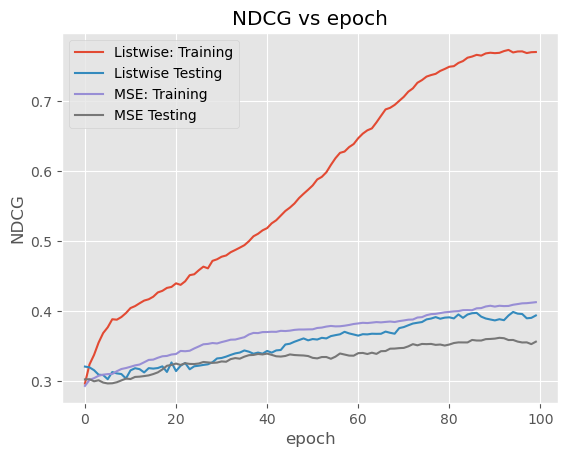

In [8]:
epochs = 100

cached_train = tf_train_ranking.shuffle(100_000).batch(8192).cache()
cached_test = tf_test_ranking.batch(4096).cache()

mse_model = RankingModelSimple(loss=tf.keras.losses.MeanSquaredError())
mse_model.compile(
    # loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.legacy.Adagrad(0.1)
)

mse_history = mse_model.fit(
    cached_train, 
    validation_data=cached_test,
    # validation_freq=5,
    epochs=epochs, 
    verbose=False
    )

listwise_model = RankingModelSimple(tfr.keras.losses.ListMLELoss())
listwise_model.compile(optimizer=tf.keras.optimizers.legacy.Adagrad(0.1))
listwise_history = listwise_model.fit(
    cached_train, 
    validation_data=cached_test,
    # validation_freq=5,
    epochs=epochs, 
    verbose=False
    )

import matplotlib.pyplot as plt

plt.plot(listwise_history.history["ndcg_metric"], label="Listwise: Training")
plt.plot(listwise_history.history["val_ndcg_metric"], label="Listwise Testing")

plt.plot(mse_history.history["ndcg_metric"], label="MSE: Training")
plt.plot(mse_history.history["val_ndcg_metric"], label="MSE Testing")

plt.title("NDCG vs epoch")
plt.xlabel("epoch")
plt.ylabel("NDCG")
plt.legend()
# plt.plot(mse_history.history["ndcg_metric"])

mse_model_result = mse_model.evaluate(cached_test, return_dict=True)
listwise_model_result = listwise_model.evaluate(cached_test, return_dict=True)

print("NDCG of the MSE Model: {:.4f}".format(mse_model_result["ndcg_metric"]))
print("NDCG of the ListMLE model: {:.4f}".format(listwise_model_result["ndcg_metric"]))

# Ranking Comprehensive 

This has bugs and I should spend more time to fix them. The bugs are related to adjusting Listwise inputs to differnt layers. 

In [ ]:
def _sample_list(
    feature_lists: Dict[Text, List[tf.Tensor]],
    num_examples_per_list: int,
    random_state: Optional[np.random.RandomState] = None,
    ) -> Tuple[tf.Tensor, tf.Tensor]:
    """Function for sampling a list example from given feature lists."""
    if random_state is None:
        random_state = np.random.RandomState()

    sampled_indices = random_state.choice(
        range(len(feature_lists["PRODUCT_ID"])),
        size=num_examples_per_list,
        replace=False,
    )
    dict_sampled = dict()
    for k in selected_attributes:
        dict_sampled[k] = [feature_lists[k][idx] for idx in sampled_indices]
    # There are bugs if using .ref() from tensorflow. So doing making the tf.stack manually
    return (
        tf.stack(dict_sampled["QUERY_DATE_TIMESTAMP"], 0),
        tf.stack(dict_sampled["SALES_LAST_WEEK"], 0),
        tf.stack(dict_sampled["SALES_LAST_MONTH"], 0),
        tf.stack(dict_sampled["SALES_LAST_YEAR"], 0),
        tf.stack(dict_sampled["PRICE_IN_CENTS"], 0),
        tf.stack(dict_sampled["REVIEWS"], 0),
        tf.stack(dict_sampled["CHANNEL"], 0),
        tf.stack(dict_sampled["DEVICE_TYPE"], 0),
        tf.stack(dict_sampled["VISITOR_TOKEN"], 0),
        tf.stack(dict_sampled["PRODUCT_ID"], 0),
        tf.stack(dict_sampled["MERCHANT_ID"], 0),
        tf.stack(dict_sampled["CATEGORY_ID"], 0),
        tf.stack(dict_sampled["CATEGORY_NAME"], 0),
        tf.stack(dict_sampled["MERCHANT_CITY"], 0),
        tf.stack(dict_sampled["MERCHANT_STATE"], 0),
        tf.stack(dict_sampled["MERCHANT_REGION"], 0),
        tf.stack(dict_sampled["PREVIOUS_PURCHASE"], 0),
        tf.stack(dict_sampled["FREE_SHIPPING"], 0),
        tf.stack(dict_sampled["IS_SOLD_OUT"], 0),
        tf.stack(dict_sampled["EDITOR_PICK"], 0),
        tf.stack(dict_sampled["ON_SALE"], 0),
        tf.stack(dict_sampled["QUERY_TEXT"], 0),
        tf.stack(dict_sampled["MERCHANT_NAME"], 0),
        tf.stack(dict_sampled["PRODUCT_NAME"], 0),
        tf.stack(dict_sampled["CLICK"], 0),
        tf.stack(dict_sampled["ADD_TO_CART"], 0),        
        tf.stack(dict_sampled["CONVERSION"], 0),        
        tf.stack(dict_sampled["LABEL"], 0),
    )


def _create_feature_dict() -> Dict[Text, List[tf.Tensor]]:
    """Helper function for creating an empty feature dict for defaultdict."""
    return {c: [] for c in selected_attributes}

def sample_listwise(
    tf_dataset = tf.data.Dataset,
    num_list_per_user_query: int = 10,
    num_examples_per_list: int = 10,
    seed: Optional[int] = None,
) -> tf.data.Dataset:
    """Function for converting the dataset to a listwise dataset.
    """
    random_state = np.random.RandomState(seed)

    example_lists_by_user_query = collections.defaultdict(_create_feature_dict)

    for example in tf_dataset:
        search_id = example["SEARCH_ID"].numpy()
        for k in selected_attributes:
            example_lists_by_user_query[search_id][k].append(example[k])
        
    tensor_slices = {c: [] for c in ["SEARCH_ID"] + selected_attributes}

    for search_id, feature_lists in example_lists_by_user_query.items():
        for _ in range(num_list_per_user_query):
            # Drop the user if they don't have enough records.
            if len(feature_lists["PRODUCT_ID"]) < num_examples_per_list:
                continue

            ordered_results = _sample_list(
                feature_lists,
                num_examples_per_list,
                random_state=random_state,
            )
            tensor_slices["SEARCH_ID"].append(search_id)
            for i, k in enumerate(selected_attributes):
                tensor_slices[k].append(ordered_results[i])

    return tf.data.Dataset.from_tensor_slices(tensor_slices)

def tf_dataset_shuffle(dataset: tf.data.Dataset) -> tf.data.Dataset:
    return dataset.shuffle(
        buffer_size=dataset.__len__().numpy() + 1, reshuffle_each_iteration=False
        )

tf_train_ranking = tf_dataset_shuffle(make_tf_ranking(df_train))
tf_test_ranking = tf_dataset_shuffle(make_tf_ranking(df_test))

tf_train_ranking = sample_listwise(tf_train_ranking)
tf_test_ranking = sample_listwise(tf_test_ranking)

products = tf.data.Dataset.from_tensor_slices((
    dict((df[selected_attributes]).drop_duplicates(subset=["PRODUCT_ID"]))
))
tf_product_ids = products.map(lambda x: x["PRODUCT_ID"])
assert isinstance(products, tf.data.Dataset)

In [ ]:
class UserModel(tf.keras.Model):
  
  CATEGORICAL_FEATURES = ["CHANNEL", "DEVICE_TYPE", "VISITOR_TOKEN"]
  BINARY_FEATURES = ["PREVIOUS_PURCHASE"]
  TEXT_FEATURES = ["QUERY_TEXT"]
  DATETIME_FEATURES = ["QUERY_DATE_TIMESTAMP"]

  def __init__(self, max_tokens=100_000, text_embedding_size=32, timestamp_embedding_size=32):
    
    super().__init__()
    self.max_tokens = max_tokens
    self.text_embedding_size = text_embedding_size
    self.timestamp_embedding_size = timestamp_embedding_size

    # Embedding for categorical and binary features:
    self.embedded_categorical_features = dict()
    for c in UserModel.CATEGORICAL_FEATURES + UserModel.BINARY_FEATURES:
      self.embedded_categorical_features[c] = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=categorical_metadate[c]["unique_values"],
        mask_token=None
      ),
      tf.keras.layers.Embedding(
        categorical_metadate[c]["nnique_values"],
        categorical_metadate[c]["embedding_size"]
      )])

    # Embedding for text features
    self.query_text_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)    
    self.query_text_embedding = tf.keras.Sequential([
      self.query_text_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, self.text_embedding_size, 
                                mask_zero=True
                                ),
      # Average the embedding of individual words to get one embedding vector
      # per query.
      tf.keras.layers.AveragePooling2D(pool_size=(1,4), strides=1, padding='valid'),
    ])
    self.query_text_vectorizer.adapt(unique_text_attributes_values["QUERY_TEXT"])

    # Embedding for date and tiem features
    self.timestamp_embedding = tf.keras.Sequential([
      tf.keras.layers.Discretization(timestamp_buckets.tolist()),
      tf.keras.layers.Embedding(
        len(timestamp_buckets) + 2, self.timestamp_embedding_size
      )
    ])
    self.normalized_timestamp = tf.keras.layers.Normalization(axis=None)
    self.normalized_timestamp.adapt(timestamps)

  def call(self, inputs):    
    len_visitor_features = tf.shape(inputs["VISITOR_TOKEN"])[0]

    categorical_feature_embedding = [
      self.embedded_categorical_features[c](
        tf.reshape(inputs[c], [len_visitor_features, num_examples_per_list, 1])
        ) for c in UserModel.CATEGORICAL_FEATURES + UserModel.BINARY_FEATURES
    ]

    text_feature_embedding = [
      self.query_text_embedding(
        tf.reshape(inputs["QUERY_TEXT"], [len_visitor_features, num_examples_per_list, 1])
    )]

    time_feature_embedding = [
      self.timestamp_embedding(
        tf.reshape(inputs["QUERY_DATE_TIMESTAMP"], [len_visitor_features, num_examples_per_list, 1])
      ),
      tf.reshape(self.normalized_timestamp(
        tf.reshape(inputs["QUERY_DATE_TIMESTAMP"], [len_visitor_features, num_examples_per_list, 1])
      ), [len_visitor_features, num_examples_per_list, 1, 1])
    ]

    all_embeddings = categorical_feature_embedding + text_feature_embedding + time_feature_embedding

    return tf.concat(all_embeddings, axis=3)

In [ ]:
class QueryModel(tf.keras.Model):
  """Model for encoding user queries."""

  def __init__(self, layer_sizes):
    """Model for encoding user queries.

    Args:
      layer_sizes:
        A list of integers where the i-th entry represents the number of units
        the i-th layer contains.
    """
    super().__init__()

    # We first use the user model for generating embeddings.
    self.embedding_model = UserModel()

    # Then construct the layers.
    self.dense_layers = tf.keras.Sequential()
    # self.dense_layers.add(tf.keras.layers.Input(shape=(32,))) ##Input 0 of layer "dense_10" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (32,)


    # Use the ReLU activation for all but the last layer.
    for layer_size in layer_sizes[:-1]:
      self.dense_layers.add(tf.keras.layers.Dense(layer_size, activation="relu"))

    # No activation for the last layer.
    for layer_size in layer_sizes[-1:]:
      self.dense_layers.add(tf.keras.layers.Dense(layer_size))

  def call(self, inputs):
    feature_embedding = self.embedding_model(inputs)
    return self.dense_layers(feature_embedding)

In [ ]:
class ProductModel(tf.keras.Model):

  NUMERICAL_FEATUES = ["SALES_LAST_WEEK", "SALES_LAST_MONTH", "SALES_LAST_YEAR", 
                       "PRICE_IN_CENTS", "REVIEWS"
                       ]
  CATEGORICAL_FEATURES = ["PRODUCT_ID", "MERCHANT_ID", "CATEGORY_ID", 
                          "MERCHANT_CITY", "MERCHANT_STATE", "MERCHANT_REGION"
                          ]
  BINARY_FEATURES = ["FREE_SHIPPING", "IS_SOLD_OUT", "EDITOR_PICK", "ON_SALE"]
  TEXT_FEATURES = ["PRODUCT_NAME", "MERCHANT_NAME", "CATEGORY_NAME"]  
  

  def __init__(self, max_tokens=100_000, text_embedding_size=32):
    super().__init__()
    self.max_tokens = max_tokens
    self.text_embedding_size = text_embedding_size

    # Categorical features
    self.embedded_categorical_features = dict()
    for c in ProductModel.CATEGORICAL_FEATURES + ProductModel.BINARY_FEATURES:
      self.embedded_categorical_features[c] = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=categorical_metadate[c]["unique_values"],
        mask_token=None
      ),
      tf.keras.layers.Embedding(
        categorical_metadate[c]["nnique_values"],
        categorical_metadate[c]["embedding_size"]
      )])            
          
    # Text features: PRODUCT_NAME      
    self.product_name_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)
    
    self.product_name_embedding = tf.keras.Sequential([
      self.product_name_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, 
                                self.text_embedding_size, 
                                mask_zero=True
                                ),
      tf.keras.layers.AveragePooling2D(pool_size=(1, 4), strides=1, padding='valid'),
    ])
    self.product_name_vectorizer.adapt(unique_text_attributes_values["PRODUCT_NAME"])

    # Text features: MERCHANT_NAME
    self.merchant_name_vectorizer = tf.keras.layers.TextVectorization(
      max_tokens=self.max_tokens)    
    self.merchant_name_embedding = tf.keras.Sequential([
      self.merchant_name_vectorizer,
      tf.keras.layers.Embedding(self.max_tokens, 
                                self.text_embedding_size, 
                                mask_zero=True
                                ),
      tf.keras.layers.AveragePooling2D(pool_size=(1, 4), strides=1, padding='valid'),
    ])
    self.merchant_name_vectorizer.adapt(unique_text_attributes_values["MERCHANT_NAME"])

    # Numerical Feeatures
    # Make a container of all numerical features. This is to support tf.data.Dataset dtype
    self.numerical_features_container = dict()
    for c in ProductModel.NUMERICAL_FEATUES:
      self.numerical_features_container[c] = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(10,)),
        tf.keras.layers.Dense(1),
        ])
    # Make the embedding for numerical features
    self.embedded_numerical_features = tf.keras.Sequential([
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(16),
    ])
    
  def call(self, inputs):    

    len_product_features=tf.shape(inputs["PRODUCT_ID"])[0]

    categorical_feature_embedding = [
      self.embedded_categorical_features[c](
        tf.reshape(inputs[c], [len_product_features, num_examples_per_list, 1])
        ) for c in ProductModel.CATEGORICAL_FEATURES + ProductModel.BINARY_FEATURES
    ]
    
    text_feature_embedding = [
      self.product_name_embedding(
        tf.reshape(inputs["PRODUCT_NAME"], [len_product_features, num_examples_per_list, 1])
      ),
      self.merchant_name_embedding(
        tf.reshape(inputs["MERCHANT_NAME"], [len_product_features, num_examples_per_list, 1])
      ),
    ]
    numerical_feature_embedding = [tf.reshape(self.embedded_numerical_features(
      tf.concat([
        self.numerical_features_container[c](
          tf.reshape(inputs[c], [len_product_features, num_examples_per_list, 1])
          ) for c in ProductModel.NUMERICAL_FEATUES
          ], axis=1)
    ), [len_product_features, num_examples_per_list, 1, -1])]

    numerical_feature_embedding = [tf.reshape(self.embedded_numerical_features(
      tf.concat([self.numerical_features_container[c](inputs[c]) for c in ProductModel.NUMERICAL_FEATUES], axis=1)
    ), [len_product_features, num_examples_per_list, 1, 1])]

    features_embeddings = categorical_feature_embedding + text_feature_embedding + numerical_feature_embedding

    return tf.concat(features_embeddings, axis=3)

In [ ]:
class CandidateModel(tf.keras.Model):
  """Model for encoding movies."""

  def __init__(self, layer_sizes):
    """Model for encoding movies.

    Args:
      layer_sizes:
        A list of integers where the i-th entry represents the number of units
        the i-th layer contains.
    """
    super().__init__()

    self.embedding_model = ProductModel()

    # Then construct the layers.
    self.dense_layers = tf.keras.Sequential()

    # Use the ReLU activation for all but the last layer.
    for layer_size in layer_sizes[:-1]:
      self.dense_layers.add(tf.keras.layers.Dense(layer_size, activation="relu"))

    # No activation for the last layer.
    for layer_size in layer_sizes[-1:]:
      self.dense_layers.add(tf.keras.layers.Dense(layer_size))

  def call(self, inputs):
    feature_embedding = self.embedding_model(inputs)
    return self.dense_layers(feature_embedding)

In [ ]:
class RankingModel(tfrs.models.Model):

  QUERY_FEATURES = UserModel.CATEGORICAL_FEATURES + \
    UserModel.BINARY_FEATURES + \
    UserModel.TEXT_FEATURES + \
    UserModel.DATETIME_FEATURES

  CANDIDATE_FEATURES = ProductModel.CATEGORICAL_FEATURES + \
    ProductModel.BINARY_FEATURES + \
    ProductModel.TEXT_FEATURES + \
    ProductModel.NUMERICAL_FEATUES  

  def __init__(self, layer_sizes):
    super().__init__()
    self.query_model = QueryModel(layer_sizes)
    self.candidate_model = CandidateModel(layer_sizes)
    self.rating_model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1),
    ])
    self.rating_task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
        loss=tfr.keras.losses.ListMLELoss(),
        metrics=[tfr.keras.metrics.NDCGMetric(name="ndcg_metric"),
                 tf.keras.metrics.RootMeanSquaredError()],
    )

  def call(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
    self.query_embeddings = self.query_model({
      c: features[c] for c in RankingModel.QUERY_FEATURES
    })
    self.candidate_embeddings = self.candidate_model({
      c: features[c] for c in RankingModel.CANDIDATE_FEATURES
    })

    # list_length = features["PRODUCT_NAME"].shape[1]
    # self.query_embeddings_repeated = tf.repeat(
    #     tf.expand_dims(tf.expand_dims(self.query_embeddings, 1), 1), [list_length], axis=1)
    # self.embedding=tf.concat([self.query_embeddings_repeated, self.candidate_embeddings], 3)
    # self.query_embeddings = tf.reshape(self.query_embeddings, [-1, list_length, 1, self.query_embeddings.shape[-1]])

    self.embedding = tf.concat([self.query_embeddings, self.candidate_embeddings], 3)

    return (
        self.query_embeddings,
        self.candidate_embeddings,
        self.rating_model(
            self.embedding
        ),
    )
  
  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    ratings = features.pop("LABEL")
    user_embeddings, product_embeddings, rating_predictions = self(features)
    rating_loss = self.rating_task(
        labels=ratings,
        predictions=tf.squeeze(tf.squeeze(rating_predictions, axis=-1), axis=-1), ## when loss used in MLE then rating_prediction must be of rank 2 this is mandatory hence we use squeez here.
    )
    # retrieval_loss = self.retrieval_task(user_embeddings, product_embeddings)

    return (rating_loss)

In [ ]:
epochs = 100

cached_train = tf_train_ranking.shuffle(100_000).batch(8192).cache()
cached_test = tf_test_ranking.batch(4096).cache()

In [ ]:
model = RankingModel(layer_sizes=[32])
model.compile(optimizer=tf.keras.optimizers.Adagrad(0.1))

model_hist = model.fit(cached_train, epochs=10)
metrics = model.evaluate(cached_test, return_dict=True)

print(f"Ranking RMSE: {metrics['root_mean_squared_error']:.3f}.")